In [1]:
#TASK 1: Date Feature Engineering
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42

df = pd.read_csv("C:/Users/Radha/Downloads/q3_retail_promotions.csv",
                 parse_dates=['transaction_date'])

print(f"Shape : {df.shape}")
print(f"\nDate range:")
print(f"  From : {df['transaction_date'].min().date()}")
print(f"  To   : {df['transaction_date'].max().date()}")
print(f"\nFirst 3 rows:")
print(df.head(3).to_string())

Shape : (1200, 9)

Date range:
  From : 2022-01-01
  To   : 2024-12-31

First 3 rows:
  transaction_date  store_id store_size location_type  promotion_type  is_weekend  is_festival  competition_density  items_sold
0       2022-01-01        28      small    semi-urban       free_gift           1            0                    5         224
1       2022-01-01         5     medium    semi-urban       free_gift           1            1                    1         348
2       2022-01-02        13      small    semi-urban  loyalty_points           1            0                    6         249


In [2]:
#Extracting date features from transaction_date
df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("Sample of new date features:")
print(df[['transaction_date', 'year', 'month',
          'day_of_week', 'is_month_end']].head(10).to_string())
print()
print(f"is_month_end distribution:")
print(df['is_month_end'].value_counts())

Sample of new date features:
  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0
5       2022-01-03  2022      1            0             0
6       2022-01-04  2022      1            1             0
7       2022-01-04  2022      1            1             0
8       2022-01-05  2022      1            2             0
9       2022-01-05  2022      1            2             0

is_month_end distribution:
is_month_end
0    959
1    241
Name: count, dtype: int64


### Date Feature Engineering — Observations

Four new features were extracted from the transaction_date column.

The year captures any overall growth or decline trend across the
three years of data. The month captures seasonal patterns such as
higher sales in festive months. The day_of_week captures weekly
rhythm — weekends typically behave differently from weekdays.
The is_month_end flag marks the final week of each month, when
many stores run end-of-month promotions or customers spend
remaining budgets.

In [3]:
#TASK 2: Temporal Train/Test Split

df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:split_idx].copy()
test_df  = df_sorted.iloc[split_idx:].copy()

print(f"Total rows : {len(df_sorted)}")
print(f"Split index: {split_idx}")
print()
print(f"Training set : {len(train_df)} rows")
print(f"  From : {train_df['transaction_date'].min().date()}")
print(f"  To   : {train_df['transaction_date'].max().date()}")
print()
print(f"Test set     : {len(test_df)} rows")
print(f"  From : {test_df['transaction_date'].min().date()}")
print(f"  To   : {test_df['transaction_date'].max().date()}")

Total rows : 1200
Split index: 960

Training set : 960 rows
  From : 2022-01-01
  To   : 2024-06-11

Test set     : 240 rows
  From : 2024-06-12
  To   : 2024-12-31


### Why a random split is inappropriate here

This dataset is ordered by time. A random split would mix future
records into the training set and past records into the test set.
The model would effectively be learning from information it could
not have had at prediction time.

In [4]:
#TASK 3: Preprocessing
from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

TARGET = 'items_sold'

feature_cols = ['store_size', 'location_type', 'promotion_type',
                'is_weekend', 'is_festival', 'competition_density',
                'year', 'month', 'day_of_week', 'is_month_end']

categorical_features = ['promotion_type', 'location_type', 'store_size']
numeric_features     = [c for c in feature_cols
                        if c not in categorical_features]

print(f"Categorical features : {categorical_features}")
print(f"Numeric features     : {numeric_features}")
print()

X_train = train_df[feature_cols]
y_train = train_df[TARGET]
X_test  = test_df[feature_cols]
y_test  = test_df[TARGET]

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', ohe,              categorical_features),
])

print("Preprocessor built successfully.")
print()
print("It will apply:")
print("  StandardScaler  → to numeric features")
print("  OneHotEncoder   → to categorical features")

Categorical features : ['promotion_type', 'location_type', 'store_size']
Numeric features     : ['is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

Preprocessor built successfully.

It will apply:
  StandardScaler  → to numeric features
  OneHotEncoder   → to categorical features


### Preprocessing Pipeline

A ColumnTransformer was used to apply different preprocessing
steps to different types of columns in a single operation.

StandardScaler was applied to all numeric features to bring them
onto the same scale. OneHotEncoder was applied to the three
categorical columns — promotion_type, location_type, and
store_size — converting each into binary columns.

In [5]:
#TASK 4: Train and Evaluate Both Models
from sklearn.linear_model  import LinearRegression
from sklearn.ensemble      import RandomForestRegressor
from sklearn.pipeline      import Pipeline
from sklearn.metrics       import mean_squared_error, mean_absolute_error

pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model',        LinearRegression()),
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model',        RandomForestRegressor(
                             n_estimators=200,
                             random_state=SEED,
                             n_jobs=1)),
    ]),
}

results  = []
preds    = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    preds[name] = y_pred

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    results.append({'Model': name, 'RMSE': round(rmse, 2),
                                   'MAE' : round(mae,  2)})
    print(f"{name}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAE  : {mae:.2f}")
    print()

results_df = pd.DataFrame(results).set_index('Model')
print("Summary:")
print(results_df)

Linear Regression
  RMSE : 27.13
  MAE  : 21.07

Random Forest
  RMSE : 31.17
  MAE  : 25.14

Summary:
                    RMSE    MAE
Model                          
Linear Regression  27.13  21.07
Random Forest      31.17  25.14


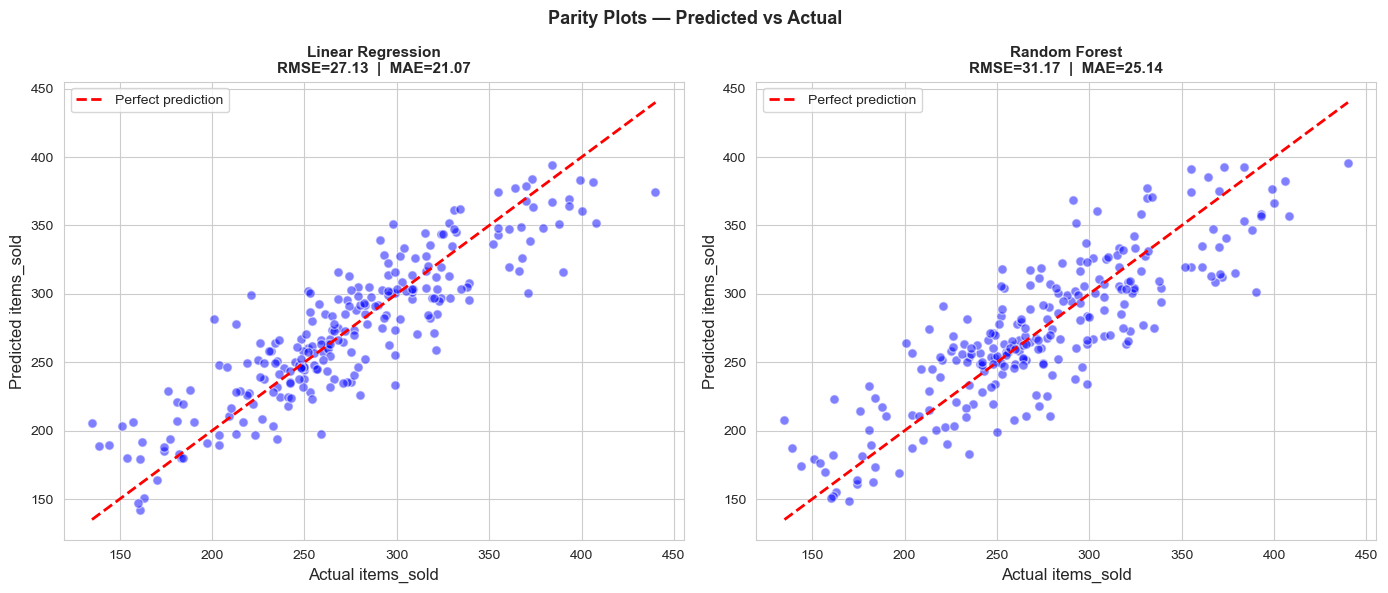

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_test, y_pred, alpha=0.5, color='Blue',
               edgecolors='white', s=45)

    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2,
            label='Perfect prediction')

    rmse = results_df.loc[name, 'RMSE']
    mae  = results_df.loc[name, 'MAE']
    ax.set_xlabel('Actual items_sold',    fontsize=12)
    ax.set_ylabel('Predicted items_sold', fontsize=12)
    ax.set_title(f'{name}\nRMSE={rmse}  |  MAE={mae}',
                 fontsize=11, fontweight='bold')
    ax.legend()

fig.suptitle('Parity Plots — Predicted vs Actual',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Top 5 most influential features:
            feature  importance
        is_festival    0.176316
   store_size_small    0.162885
location_type_urban    0.112153
        day_of_week    0.095676
competition_density    0.062609


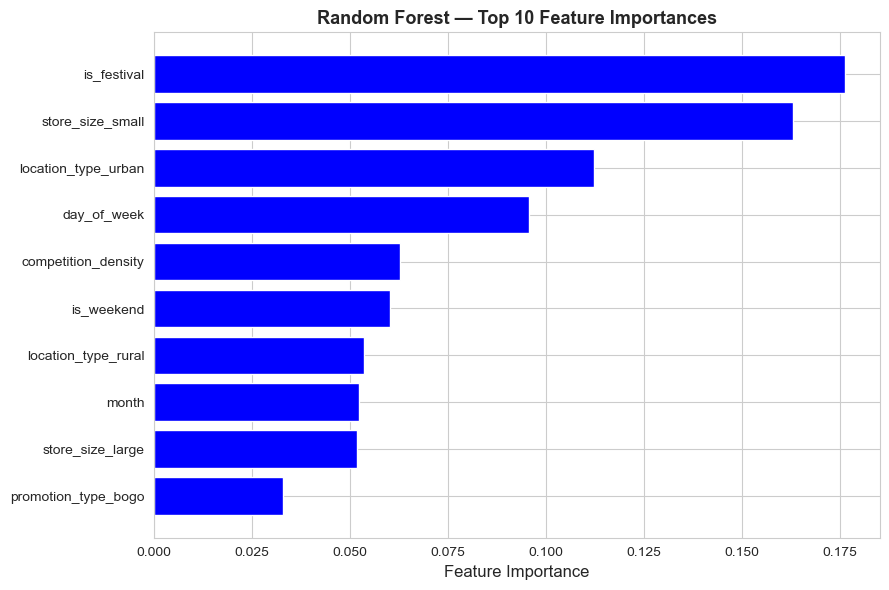

In [7]:
#Random Forest
rf_pipeline = pipelines['Random Forest']
rf_model    = rf_pipeline.named_steps['model']
fitted_pre  = rf_pipeline.named_steps['preprocessor']

num_names = numeric_features
try:
    cat_names = fitted_pre.named_transformers_['cat']\
                    .get_feature_names_out(categorical_features).tolist()
except AttributeError:
    cat_names = fitted_pre.named_transformers_['cat']\
                    .get_feature_names(categorical_features).tolist()

all_feature_names = num_names + cat_names

importances_df = pd.DataFrame({
    'feature'   : all_feature_names,
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 5 most influential features:")
print(importances_df.head(5).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
top10 = importances_df.head(10).iloc[::-1]
ax.barh(top10['feature'], top10['importance'], color='Blue')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Random Forest — Top 10 Feature Importances',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Model Evaluation — Observations

Linear Regression outperformed Random Forest on both metrics
(RMSE 27.13 vs 31.17, MAE 21.07 vs 25.14). This suggests the
relationship between the features and items_sold is largely
additive and linear — store size, location, promotion type and
festival flags each contribute independently to sales volume,
without strong interactions that would require a more complex model.

The parity plots confirm this — Linear Regression predictions
cluster more tightly around the diagonal reference line, while
Random Forest shows slightly more scatter.

The top 5 features identified by the Random Forest were the most
influential drivers of items_sold. Festival days, store size, and
location type dominated, reflecting that external conditions and
store characteristics matter more than the specific promotion
being run.